## Import data


In [4]:
import polars as pl
import datetime as dt

af2_cutoff = dt.datetime(2018, 5, 1, tzinfo=dt.timezone.utc)
boltz_cutoff = dt.datetime(2023, 6, 1, tzinfo=dt.timezone.utc)

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")
pdb_af3 = pdb_af3.with_columns(
    pl.when(pl.col("pdb_date") < af2_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("af2_pre_cutoff")
)
pdb_boltz = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet"
).with_columns(
    pl.when(pl.col("pdb_date") < boltz_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("boltz_pre_cutoff")
)

## Plotting methods


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats


def plot_rmsd_compare(
    df_af3: pl.DataFrame,
    df_boltz: pl.DataFrame,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Compare a single RMSD type between AF3 and Boltz models.
    For each model we plot two boxplots (pre- and post-training cutoff),
    annotate legend entries with sample counts, and compute
    Spearman correlation + two-sided paired t-test on matching PDB IDs.
    """
    # Column names
    col_af3 = f"{rmsd_type}_rmsd_af3_4"
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"
    col_af2 = "cdr_rmsd"

    # Prepare pre/post subsets and counts
    af3_pre = df_af3.filter(pl.col("replication"))
    af3_post = df_af3.filter(~pl.col("replication"))
    af2_pre = df_af3.filter(pl.col("af2_pre_cutoff"))
    af2_post = df_af3.filter(~pl.col("af2_pre_cutoff"), pl.col(col_af2).is_not_null())
    bolt_pre = df_boltz.filter(pl.col("boltz_pre_cutoff"))
    bolt_post = df_boltz.filter(~pl.col("boltz_pre_cutoff"))

    n_af2_pre = af2_pre.height
    n_af2_post = af2_post.height
    n_af3_pre = af3_pre.height
    n_af3_post = af3_post.height
    n_bolt_pre = bolt_pre.height
    n_bolt_post = bolt_post.height

    # Boxplot data
    pre_af2_vals = af2_pre.select(pl.col(col_af2)).to_numpy().flatten()
    post_af2_vals = af2_post.select(pl.col(col_af2)).to_numpy().flatten()
    pre_af3_vals = af3_pre.select(pl.col(col_af3)).to_numpy().flatten()
    post_af3_vals = af3_post.select(pl.col(col_af3)).to_numpy().flatten()
    pre_bolt_vals = bolt_pre.select(pl.col(col_boltz)).to_numpy().flatten()
    post_bolt_vals = bolt_post.select(pl.col(col_boltz)).to_numpy().flatten()

    # Set up plot
    x = np.array([0, 1, 2])
    width = 0.3
    fig, ax = plt.subplots(figsize=(8, 5))

    # plot AF2
    ax.boxplot(
        pre_af2_vals,
        positions=[x[0] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:purple", edgecolor="black"),
        whiskerprops=dict(color="tab:purple"),
        capprops=dict(color="tab:purple"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:purple"),
    )
    ax.boxplot(
        post_af2_vals,
        positions=[x[0] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:brown", edgecolor="black"),
        whiskerprops=dict(color="tab:brown"),
        capprops=dict(color="tab:brown"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:brown"),
    )

    # Plot AF3
    ax.boxplot(
        pre_af3_vals,
        positions=[x[1] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        post_af3_vals,
        positions=[x[1] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # Plot Boltz
    ax.boxplot(
        pre_bolt_vals,
        positions=[x[2] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:green", edgecolor="black"),
        whiskerprops=dict(color="tab:green"),
        capprops=dict(color="tab:green"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:green"),
    )
    ax.boxplot(
        post_bolt_vals,
        positions=[x[2] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:red", edgecolor="black"),
        whiskerprops=dict(color="tab:red"),
        capprops=dict(color="tab:red"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:red"),
    )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels(["AF2M-TCRDock", "AF3", "Boltz"])
    ax.set_ylabel(f"{rmsd_type.upper()} RMSD (Å)")
    if title:
        ax.set_title(title)

    # Legend with counts
    legend_handles = [
        Patch(
            facecolor="tab:purple", edgecolor="black", label=f"AF2 pre (n={n_af2_pre})"
        ),
        Patch(
            facecolor="tab:brown", edgecolor="black", label=f"AF2 post (n={n_af2_post})"
        ),
        Patch(
            facecolor="tab:blue", edgecolor="black", label=f"AF3 pre (n={n_af3_pre})"
        ),
        Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label=f"AF3 post (n={n_af3_post})",
        ),
        Patch(
            facecolor="tab:green",
            edgecolor="black",
            label=f"Boltz pre (n={n_bolt_pre})",
        ),
        Patch(
            facecolor="tab:red",
            edgecolor="black",
            label=f"Boltz post (n={n_bolt_post})",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    ax.legend(handles=legend_handles, loc="upper right")

    plt.tight_layout()
    return fig

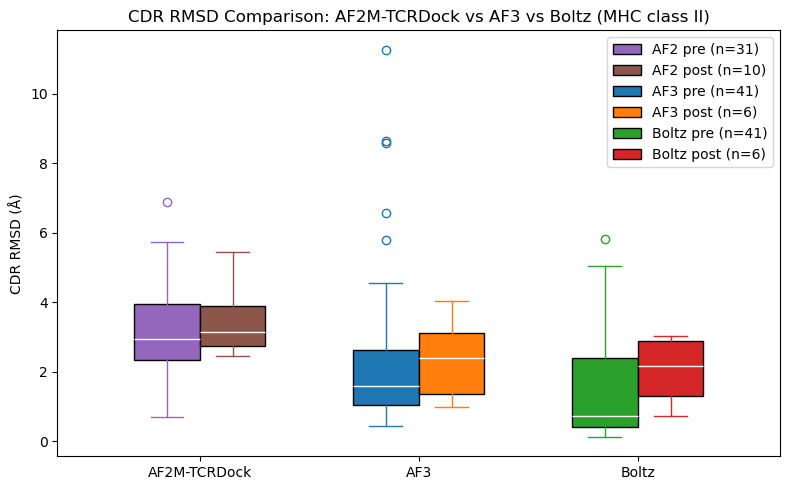

In [10]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "cdr",
    title="CDR RMSD Comparison: AF2M-TCRDock vs AF3 vs Boltz (MHC class II)",
)

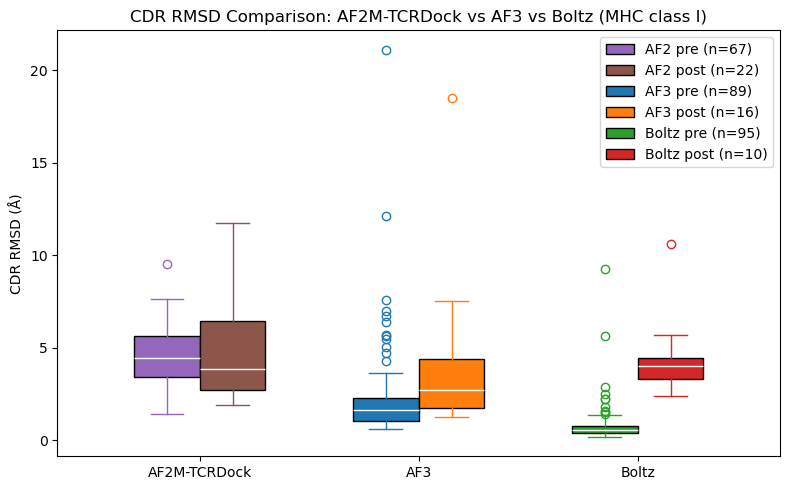

In [11]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "cdr",
    title="CDR RMSD Comparison: AF2M-TCRDock vs AF3 vs Boltz (MHC class I)",
)